### Load data and basic inspection

In [1]:
import pandas as pd

df = pd.read_csv("../data/cleveland_heart.csv")
df.head()
df.info()
df['target'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        299 non-null    float64
 12  thal      301 non-null    float64
 13  num       303 non-null    int64  
 14  target    303 non-null    int64  
dtypes: float64(3), int64(12)
memory usage: 35.6 KB


target
0    164
1    139
Name: count, dtype: int64

### Histograms for key features

<Figure size 1500x1000 with 0 Axes>

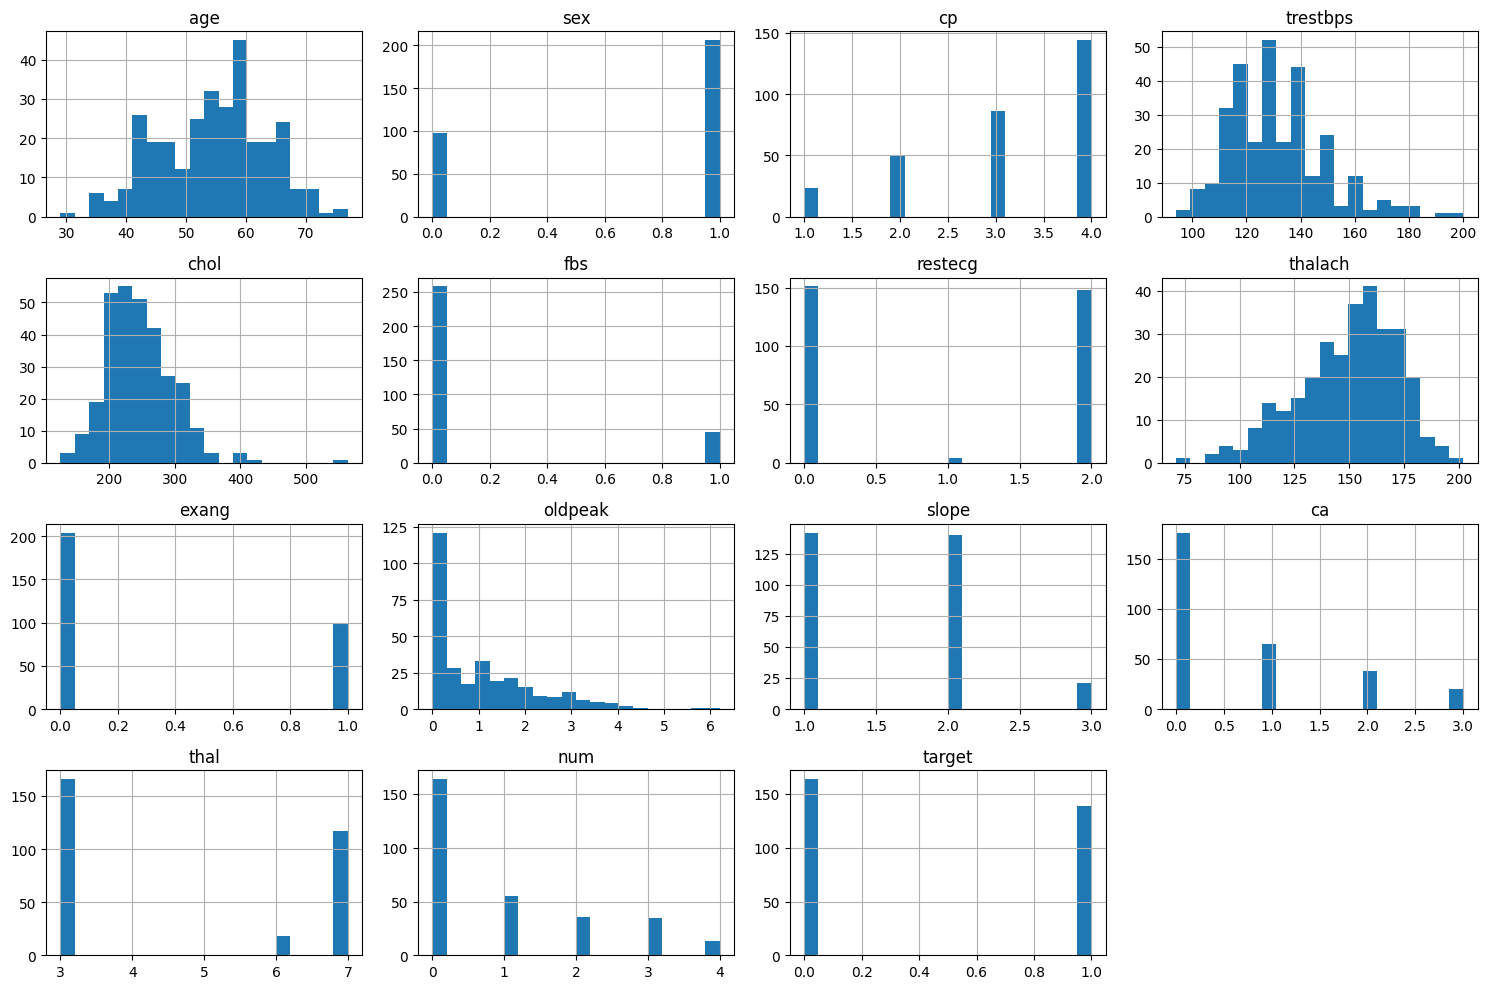

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

numeric_cols = df.select_dtypes(include=["int64", "float64"]).columns

plt.figure(figsize=(15, 10))
df[numeric_cols].hist(figsize=(15, 10), bins=20)
plt.tight_layout()
plt.savefig('histogram.png', dpi=300, bbox_inches='tight')

### Class distribution plot

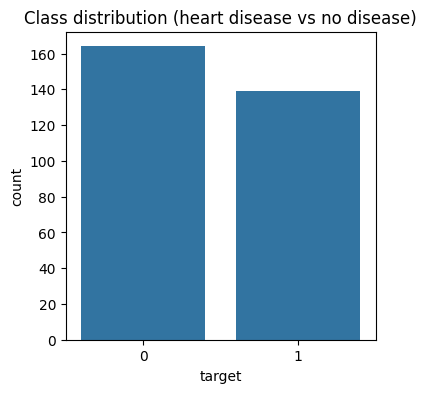

In [4]:
plt.figure(figsize=(4, 4))
sns.countplot(x="target", data=df)
plt.title("Class distribution (heart disease vs no disease)")
plt.savefig('class_distribution.png', dpi=300, bbox_inches='tight')

### Correlation heatmap

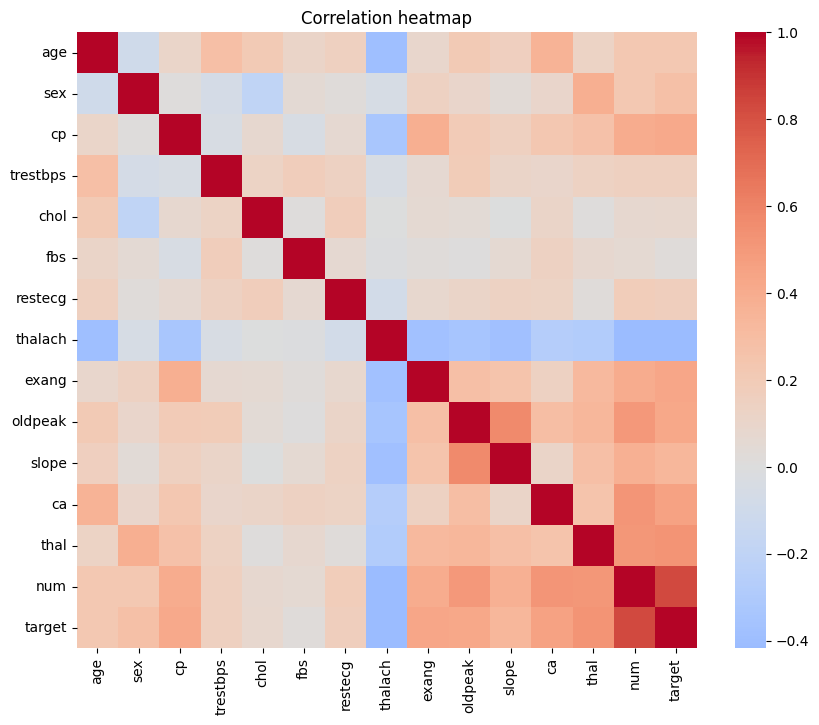

In [5]:
plt.figure(figsize=(10, 8))
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=False, cmap="coolwarm", center=0)
plt.title("Correlation heatmap")
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')

### Missing value analysis

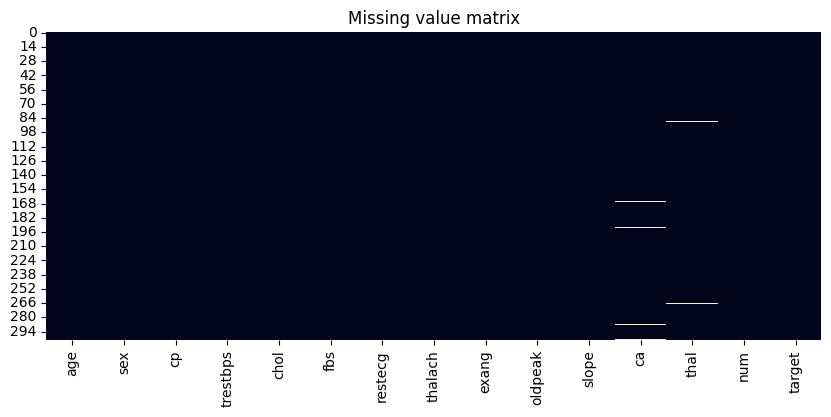

In [6]:
df.isnull().sum()

plt.figure(figsize=(10, 4))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing value matrix")
plt.savefig('missing_values.png', dpi=300, bbox_inches='tight')

### Feature relationship analysis

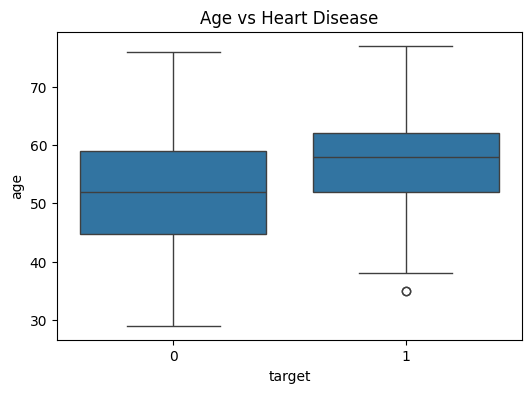

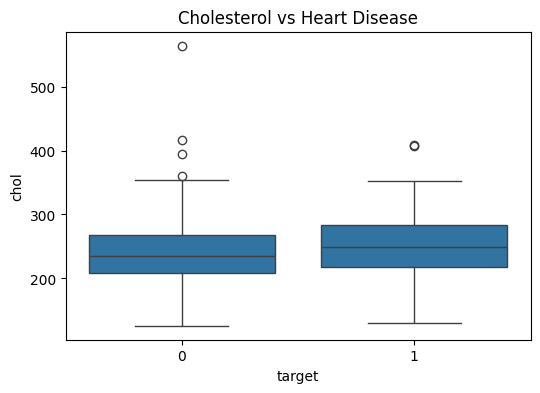

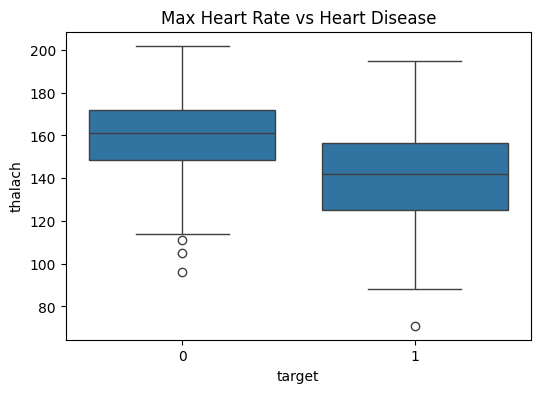

In [7]:
plt.figure(figsize=(6, 4))
sns.boxplot(x="target", y="age", data=df)
plt.title("Age vs Heart Disease")
plt.savefig('agevshd.png', dpi=300, bbox_inches='tight')

plt.figure(figsize=(6, 4))
sns.boxplot(x="target", y="chol", data=df)
plt.title("Cholesterol vs Heart Disease")
plt.savefig('cholvshd.png', dpi=300, bbox_inches='tight')

plt.figure(figsize=(6, 4))
sns.boxplot(x="target", y="thalach", data=df)
plt.title("Max Heart Rate vs Heart Disease")
plt.savefig('thalachvshd.png', dpi=300, bbox_inches='tight')

### Handling missing values and Encoding

In [7]:
df.isna().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
num         0
target      0
dtype: int64

In [8]:
numeric_features = ["age", "trestbps", "chol", "thalach", "oldpeak"]
categorical_features = ["sex", "cp", "fbs", "restecg",
                        "exang", "slope", "ca", "thal"]

target_col = "target"

We exclude 'num' column from the feature list because it is the original label column, not an input feature, and we explicitly want a binary target (presence/absence of heart disease) derived from it.

What num represents?
On the UCI Heart Disease page, the authors define:

The “predicted attribute” is num, taking values 0–4.

- 0 -> no heart disease.

- 1, 2, 3, 4 -> varying degrees of disease presence.

In most ML work, this multi‑class label is collapsed to a binary classification problem: “disease present or not”.

We intentionally exclude num because:

- As the label, num should not be fed into the model as an input feature (that would leak the answer and break the learning problem).

In [13]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

def load_raw_data(path: str = "data/cleveland_heart.csv") -> pd.DataFrame:
    df = pd.read_csv(path)
    return df

def build_preprocessor() -> ColumnTransformer:
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features),
        ]
    )
    return preprocessor

In [14]:
X = df[numeric_features + categorical_features]
y = df[target_col]

# Fit the preprocessor and transform X
X_processed = preprocessor.fit_transform(X)

X_processed.shape

(303, 28)

In [15]:
feature_names = preprocessor.get_feature_names_out()
feature_names[:20]

array(['num__age', 'num__trestbps', 'num__chol', 'num__thalach',
       'num__oldpeak', 'cat__sex_0.0', 'cat__sex_1.0', 'cat__cp_1.0',
       'cat__cp_2.0', 'cat__cp_3.0', 'cat__cp_4.0', 'cat__fbs_0.0',
       'cat__fbs_1.0', 'cat__restecg_0.0', 'cat__restecg_1.0',
       'cat__restecg_2.0', 'cat__exang_0.0', 'cat__exang_1.0',
       'cat__slope_1.0', 'cat__slope_2.0'], dtype=object)

### Summary

We can see from the initial EDA that, we have 14 features and 1 target column with 303 entries. The data is in int and float datatypes. We can also see that we have missing values is 'ca' and 'thal' columns which is again validated from the Missing Value Analysis plot. Class balance shows that we have more cases of absence of heart disease compared to presence of heart disease. Correlation analysis shows that some features like 'age' and 'ca' are positively correlated, wheres some features like 'age' and 'thalach' are negatively correlated. 

We have also handled all the missing values through imputation. Categorical features are encoded into one-hot vectors. This preprocessor will be reused in model training and serving to ensure reproducibility.